# Solar home electricity data

Source: http://www.ausgrid.com.au/Common/About-us/Corporate-information/Data-to-share/Solar-home-electricity-data.aspx

PH April-May 2017

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [3]:
%matplotlib inline

In [4]:
pd.__version__

'2.2.3'

## Load raw data

In [5]:
# fname = 'data/Solar home 2011-2012.csv'
fname = '../data/ausgrid/2011-2012 Solar home electricity data.csv'

In [6]:
!head -n 3 "$fname"

"2011-2012 Solar home electricity data - Before using this data, please read the attached pdf document ""Ausgrid solar home electricity data notes (Aug 2014).pdf""",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,3:00,3:30,4:00,4:30,5:00,5:30,6:00,6:30,7:00,7:30,8:00,8:30,9:00,9:30,10:00,10:30,11:00,11:30,12:00,12:30,13:00,13:30,14:00,14:30,15:00,15:30,16:00,16:30,17:00,17:30,18:00,18:30,19:00,19:30,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
1,3.78,2076,CL,1/07/2011,1.25,1.25,1.25,0.625,0.219,1.013,0,0,0.125,0.894,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.063,


### Parse CSV

(nb: parsing date is quite long):

In [7]:
d_raw = pd.read_csv(fname, skiprows=1,
                    parse_dates=['date'], dayfirst=True,
                    na_filter=False, dtype={'Row Quality': str})
len(d_raw)

270304

### Overview

rows seems ordered by: Customer / Consumption Category / date

In [8]:
d_raw.head()

,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
0,1,3.78,2076,CL,2011-07-01,1.250,1.250,1.250,0.625,0.219,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.063,
1,1,3.78,2076,GC,2011-07-01,1.077,0.669,0.674,0.615,0.321,...,0.276,0.241,0.168,0.234,0.164,0.639,0.118,0.219,0.162,
2,1,3.78,2076,GG,2011-07-01,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,
3,1,3.78,2076,CL,2011-07-02,1.238,1.244,1.194,0.000,0.888,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.075,
4,1,3.78,2076,GC,2011-07-02,0.476,0.130,0.044,0.094,0.032,...,0.234,0.306,0.183,0.240,0.170,0.506,0.224,0.088,0.084,


In [9]:
d_raw.tail()

,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
270299,300,3.36,2086,GC,2012-06-29,0.082,0.129,0.084,0.123,0.091,...,0.496,0.387,0.357,0.387,0.408,0.527,0.517,0.393,0.226,
270300,300,3.36,2086,GG,2012-06-29,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,
270301,300,3.36,2086,CL,2012-06-30,2.110,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.621,
270302,300,3.36,2086,GC,2012-06-30,0.247,0.193,0.109,0.115,0.096,...,1.526,0.799,0.822,0.244,0.200,0.204,0.131,0.358,0.235,
270303,300,3.36,2086,GG,2012-06-30,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,


### Details on major columns

#### Post codes: 

* 100 different codes
* between 2008 and 2330, which corresponds to New South Wales (cf. [Postcodes_in_Australia](https://en.wikipedia.org/wiki/Postcodes_in_Australia)), as said by Ausgrid
* Postcode geocoding: [Postcodes location.ipynb](Postcodes location.ipynb)
* Geocoding output: [postcodes.csv](postcodes/postcodes.csv)

![New South Wales](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a8/New_South_Wales_in_Australia.svg/267px-New_South_Wales_in_Australia.svg.png)

In [10]:
len(d_raw.Postcode.unique())

100

In [11]:
print(sorted(d_raw.Postcode.unique()))

[np.int64(2008), np.int64(2010), np.int64(2018), np.int64(2021), np.int64(2025), np.int64(2026), np.int64(2029), np.int64(2031), np.int64(2034), np.int64(2037), np.int64(2039), np.int64(2041), np.int64(2044), np.int64(2046), np.int64(2047), np.int64(2048), np.int64(2066), np.int64(2074), np.int64(2076), np.int64(2077), np.int64(2079), np.int64(2081), np.int64(2082), np.int64(2084), np.int64(2085), np.int64(2086), np.int64(2087), np.int64(2088), np.int64(2092), np.int64(2093), np.int64(2096), np.int64(2099), np.int64(2100), np.int64(2111), np.int64(2119), np.int64(2120), np.int64(2126), np.int64(2134), np.int64(2135), np.int64(2137), np.int64(2154), np.int64(2159), np.int64(2162), np.int64(2190), np.int64(2196), np.int64(2198), np.int64(2200), np.int64(2203), np.int64(2204), np.int64(2205), np.int64(2207), np.int64(2208), np.int64(2209), np.int64(2211), np.int64(2216), np.int64(2218), np.int64(2219), np.int64(2220), np.int64(2224), np.int64(2227), np.int64(2228), np.int64(2229), np.int6

#### Dates

* `parse_date` option is working (although quite slow)
* `dayfirst=True` is needed to avoid date inversions

In [12]:
d_raw.date.head()

0   2011-07-01
1   2011-07-01
2   2011-07-01
3   2011-07-02
4   2011-07-02
Name: date, dtype: datetime64[ns]

In [13]:
%time min(d_raw.date)

CPU times: user 138 ms, sys: 3.09 ms, total: 141 ms
Wall time: 141 ms


Timestamp('2011-07-01 00:00:00')

In [14]:
%time d_raw.date.min()

CPU times: user 608 µs, sys: 67 µs, total: 675 µs
Wall time: 526 µs


Timestamp('2011-07-01 00:00:00')

In [15]:
d0, d1 = d_raw.date.min(), d_raw.date.max()
d0, d1

(Timestamp('2011-07-01 00:00:00'), Timestamp('2012-06-30 00:00:00'))

#### Row Quality:

Ausgrid description:
> (Blank) = every half hour value in the row is the actual electricity
recorded by the meter in the half hour
>
> NA = Non-Actual where some or all of the half hour values in the
row are estimates or substitutes of the electricity consumed or
generated

Specifying the `dtype={'Row Quality': str}` is needed to avoid a columns of dtype float, filled with NaN.

In [16]:
d_raw['Row Quality'].unique()

array(['', 'NA'], dtype=object)

In [17]:
d_raw['Row Quality'].value_counts()

Row Quality
      270204
NA       100
Name: count, dtype: int64

#### Customers

300 unique values, from 1 to 300

In [18]:
len(d_raw['Customer'].unique())

300

In [19]:
d_raw['Customer'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

#### Consumption Category (aka measurement channel)

From Ausgrid description:

> **GC** = General Consumption for electricity supplied all the time
(primary tariff, either inclining block or time of use rates),
excluding solar generation and controlled load supply

> **CL** = Controlled Load Consumption (Off peak 1 or 2 tariffs)

> **GG** = Gross Generation for electricity generated by the solar
system with a gross metering configuration, measured separately
to household loads

Observation: only half as much CL as GG and GC.


In [20]:
d_raw['Consumption Category'].unique()

array(['CL', 'GC', 'GG'], dtype=object)

In [21]:
d_raw['Consumption Category'].value_counts()

Consumption Category
GC    109800
GG    109800
CL     50704
Name: count, dtype: int64

### Completeness of the record

there are some missing records in the dataframe:

* GG and GC is complete
* Some 54% of CL is missing.

In [22]:
len(d_raw)/366/300

2.461785063752277

In [23]:
d_raw['Consumption Category'].value_counts()/300/366

Consumption Category
GC    1.000000
GG    1.000000
CL    0.461785
Name: count, dtype: float64

## 2) Reshaping the data set.

Objective:

* Stack the time, to get proper timestamp combining day and hour
* pivot the customer and consumption category as columns

### Create datetime index

In [24]:
from pandas.tseries.offsets import Day

In [25]:
d1

Timestamp('2012-06-30 00:00:00')

In [26]:
d1 + Day(1)

Timestamp('2012-07-01 00:00:00')

Create the index, with **"left" convention** (start of the 30min interval), to make slicing for a given day easier

In [27]:
index = pd.date_range(d0, d1 + Day(1), freq='30T', inclusive='left')
index

/tmp/ipykernel_94357/2707357368.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index = pd.date_range(d0, d1 + Day(1), freq='30T', inclusive='left')


DatetimeIndex(['2011-07-01 00:00:00', '2011-07-01 00:30:00',
               '2011-07-01 01:00:00', '2011-07-01 01:30:00',
               '2011-07-01 02:00:00', '2011-07-01 02:30:00',
               '2011-07-01 03:00:00', '2011-07-01 03:30:00',
               '2011-07-01 04:00:00', '2011-07-01 04:30:00',
               ...
               '2012-06-30 19:00:00', '2012-06-30 19:30:00',
               '2012-06-30 20:00:00', '2012-06-30 20:30:00',
               '2012-06-30 21:00:00', '2012-06-30 21:30:00',
               '2012-06-30 22:00:00', '2012-06-30 22:30:00',
               '2012-06-30 23:00:00', '2012-06-30 23:30:00'],
              dtype='datetime64[ns]', length=17568, freq='30min')

### Colums: Customer/Channel

using a MultiIndex, cf. [MultiIndex / Advanced Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) doc.

In [28]:
customers = sorted(d_raw.Customer.unique())
print(customers)

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), 

In [29]:
channels = d_raw['Consumption Category'].unique()
channels

array(['CL', 'GC', 'GG'], dtype=object)

Customized channel order:

* Consumption first (GC)
* PV Generation second (GG)
* CL third, because it is not always present (small trick to preserve the channel color in plots)

In [30]:
channels = ['GC', 'GG', 'CL']

In [31]:
columns = pd.MultiIndex.from_product(
    (customers, channels), names=['Customer', 'Channel'])
columns

MultiIndex([(  1, 'GC'),
            (  1, 'GG'),
            (  1, 'CL'),
            (  2, 'GC'),
            (  2, 'GG'),
            (  2, 'CL'),
            (  3, 'GC'),
            (  3, 'GG'),
            (  3, 'CL'),
            (  4, 'GC'),
            ...
            (297, 'CL'),
            (298, 'GC'),
            (298, 'GG'),
            (298, 'CL'),
            (299, 'GC'),
            (299, 'GG'),
            (299, 'CL'),
            (300, 'GC'),
            (300, 'GG'),
            (300, 'CL')],
           names=['Customer', 'Channel'], length=900)

### Create the new DataFrame

starting from a blank DataFrame:

In [32]:
# empty_cols = pd.MultiIndex(
#     levels=[customers, channels],
#     labels=[[],  []],
#     names=['Customer', 'Channel'])
empty_cols = pd.MultiIndex(
    levels=[customers, channels],
    codes=[[],  []],
    names=['Customer', 'Channel'])

In [33]:
df = pd.DataFrame(index=index, columns=empty_cols)
df

2011-07-01 00:00:00
2011-07-01 00:30:00
2011-07-01 01:00:00
2011-07-01 01:30:00
2011-07-01 02:00:00
...
2012-06-30 21:30:00
2012-06-30 22:00:00
2012-06-30 22:30:00
2012-06-30 23:00:00
2012-06-30 23:30:00


Fill the columns:

notice: 

* it is way slower when the 3x300 columns are pre-assigned in the DataFrame creation
* but the MultiIndex is lost when pre-assignment is not done (empty columns)
* → solution which seems to work: using an empty MultiIndex (customers/channel)

In [34]:
missing_records = []

for c in customers:
    d_c = d_raw[d_raw.Customer == c]

    # TODO: save the row quality
    print(c, end=', ')

    for ch in channels:
        d_c_ch = d_c[d_c['Consumption Category'] == ch]
        ts = d_c_ch.iloc[:,  5:-1].values.ravel()
        # if len(ts) > 0:  # Check if data length matches expected length
        #     df[c, ch] = ts
        # else:
        #     missing_records.append((c, ch, len(ts)))

        if len(ts) != len(index):
            # This excludes customers with any missing data.
            missing_records.append((c,  ch, len(ts)))
        else:
            df[c, ch] = ts

1, 2, 3, 

/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/

4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 

/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/

111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 

/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/

217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 

/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/tmp/ipykernel_94357/3108192518.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c, ch] = ts
/

#### Analysis of missing/imcomplete records

Observation: out of 162 missing records (over a potential of 900):

* 161 are the complete absence of the CL channel
* 1 is an incomplete CL channe (from 2011-07-01 to 2012-01-12): maybe a change of tariff ?

In [35]:
len(columns)

900

In [36]:
len(missing_records)

162

In [37]:
n_empty_CL = 0
missing_records_others = []
for (c, ch, len_ts) in missing_records:
    if ch == 'CL' and len_ts == 0:
        n_empty_CL += 1
    else:
        missing_records_others.append((c, ch, len_ts))
n_empty_CL

161

In [38]:
missing_records_others

[(np.int64(27), 'CL', 9408)]

In [39]:
d_27_CL = d_raw[(d_raw.Customer == 27) & (
    d_raw['Consumption Category'] == 'CL')]
d_27_CL['date'].iloc[[0, -1]]

24522   2011-07-01
25107   2012-01-12
Name: date, dtype: datetime64[ns]

#### Check the new dataframe

In [40]:
len(df.columns) + len(missing_records)

900

In [41]:
df.head()

Customer               1                  2                3                \
Channel                 GC   GG     CL     GC   GG   CL     GC   GG     CL   
2011-07-01 00:00:00  1.077  0.0  1.250  0.276  0.0  0.0  0.060  0.0  2.008   
2011-07-01 00:30:00  0.669  0.0  1.250  0.134  0.0  0.0  0.062  0.0  0.218   
2011-07-01 01:00:00  0.674  0.0  1.250  0.169  0.0  0.0  0.060  0.0  0.000   
2011-07-01 01:30:00  0.615  0.0  0.625  0.185  0.0  0.0  0.059  0.0  0.000   
2011-07-01 02:00:00  0.321  0.0  0.219  0.141  0.0  0.0  0.060  0.0  0.000   

Customer               4    ...    297                298         299       \
Channel                 GC  ...     GC   GG     CL     GC   GG     GC   GG   
2011-07-01 00:00:00  0.104  ...  0.268  0.0  0.000  0.100  0.0  0.140  0.0   
2011-07-01 00:30:00  0.107  ...  0.329  0.0  0.000  0.068  0.0  0.160  0.0   
2011-07-01 01:00:00  0.104  ...  0.306  0.0  0.000  0.068  0.0  0.116  0.0   
2011-07-01 01:30:00  0.108  ...  0.233  0.0  1.311  0.068  0.0  0.162  0.0   
2011-07-01 02:00:00  0.110  ...  0.265  0.0  0.000  0.069  0.0  0.138  0.0   

Customer               300              
Channel                 GC   GG     CL  
2011-07-01 00:00:00  1.034  0.0  2.533  
2011-07-01 00:30:00  0.631  0.0  0.265  
2011-07-01 01:00:00  0.119  0.0  0.000  
2011-07-01 01:30:00  0.098  0.0  0.000  
2011-07-01 02:00:00  0.109  0.0  0.000  

[5 rows x 738 columns]

In [42]:
df.tail()

Customer               1                  2                3                \
Channel                 GC   GG     CL     GC   GG   CL     GC     GG   CL   
2012-06-30 21:30:00  0.622  0.0  0.000  0.368  0.0  0.0  0.066  0.000  0.0   
2012-06-30 22:00:00  0.509  0.0  0.000  0.305  0.0  0.0  0.768  0.000  0.0   
2012-06-30 22:30:00  0.716  0.0  0.000  0.285  0.0  0.0  0.966  0.000  0.0   
2012-06-30 23:00:00  0.999  0.0  0.000  0.286  0.0  0.0  0.957  0.006  0.0   
2012-06-30 23:30:00  0.916  0.0  1.063  0.188  0.0  0.0  0.902  0.000  0.0   

Customer               4    ...    297                298         299       \
Channel                 GC  ...     GC   GG     CL     GC   GG     GC   GG   
2012-06-30 21:30:00  0.159  ...  0.366  0.0  0.000  0.173  0.0  1.095  0.0   
2012-06-30 22:00:00  0.134  ...  0.458  0.0  0.814  0.154  0.0  0.946  0.0   
2012-06-30 22:30:00  0.101  ...  0.305  0.0  2.369  0.150  0.0  1.834  0.0   
2012-06-30 23:00:00  0.086  ...  0.165  0.0  1.915  0.142  0.0  1.719  0.0   
2012-06-30 23:30:00  0.082  ...  0.206  0.0  0.000  0.145  0.0  1.412  0.0   

Customer               300              
Channel                 GC   GG     CL  
2012-06-30 21:30:00  0.200  0.0  0.000  
2012-06-30 22:00:00  0.204  0.0  0.000  
2012-06-30 22:30:00  0.131  0.0  0.000  
2012-06-30 23:00:00  0.358  0.0  0.000  
2012-06-30 23:30:00  0.235  0.0  2.621  

[5 rows x 738 columns]

### Unit conversion: kWh → kW → W

Energy records in the original CSV file is in kWh on the 30 min interval. Convert to kW.

In [43]:
df[1].mean()

Channel
GC    0.292210
GG    0.269105
CL    0.146694
dtype: float64

In [44]:
df *= 2

In [45]:
df[1].mean()

Channel
GC    0.584421
GG    0.538209
CL    0.293388
dtype: float64

In [46]:
# KW to W
df *= 1000

In [47]:
df[1].mean()

Channel
GC    584.420879
GG    538.209358
CL    293.388206
dtype: float64

## 3) Howto work with the reshaped DataFrame

### 3a) select *one* customer, with all its 3 channels

this easy because `customer` is the first level of the MultiIndex

In [48]:
df[1]

Channel,GC,GG,CL
2011-07-01 00:00:00,2154.0,0.0,2500.0
2011-07-01 00:30:00,1338.0,0.0,2500.0
2011-07-01 01:00:00,1348.0,0.0,2500.0
2011-07-01 01:30:00,1230.0,0.0,1250.0
2011-07-01 02:00:00,642.0,0.0,438.0
...,...,...,...
2012-06-30 21:30:00,1244.0,0.0,0.0
2012-06-30 22:00:00,1018.0,0.0,0.0
2012-06-30 22:30:00,1432.0,0.0,0.0
2012-06-30 23:00:00,1998.0,0.0,0.0


In [49]:
df[1].mean()

Channel
GC    584.420879
GG    538.209358
CL    293.388206
dtype: float64

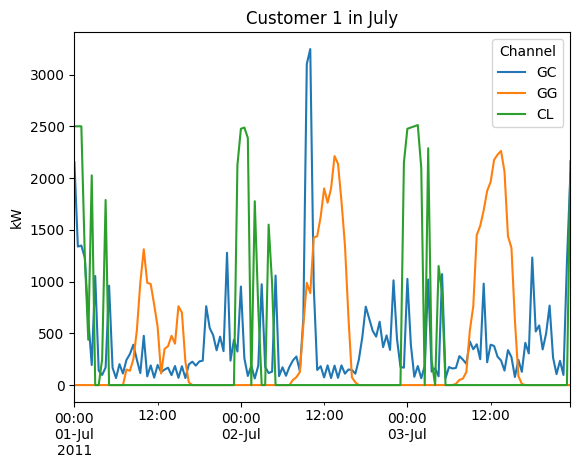

In [50]:
import os
df[1]['2011-07-01':'2011-07-03'].plot()
plt.title('Customer 1 in July')
plt.ylabel('kW')

# Create the directory if it doesn't exist
os.makedirs('../figs/ausgrid_explore', exist_ok=True)
plt.savefig('../figs/ausgrid_explore/Customer 1 2011-07 01-03.png', dpi=150)

Text(0.5, 1.0, 'Customer 100 in July (No CL)')

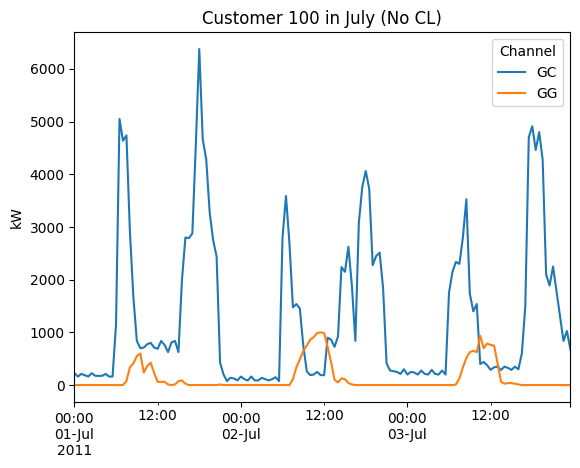

In [51]:
df[100]['2011-07-01':'2011-07-03'].plot()
plt.ylabel('kW')
plt.title('Customer 100 in July (No CL)')

### 3b) select *one* channel, across *all* customers

This is less easy because `channel` is the 2nd level of the MultiIndex.
It requires using [cross-section](http://pandas.pydata.org/pandas-docs/stable/advanced.html#cross-section) indexing with `xs`

In [52]:
dfGG = df.xs('GG', level='Channel', axis=1)
dfGG[[1, 4, 100]]

Customer,1,4,100
2011-07-01 00:00:00,0.0,0.0,0.0
2011-07-01 00:30:00,0.0,0.0,0.0
2011-07-01 01:00:00,0.0,0.0,0.0
2011-07-01 01:30:00,0.0,0.0,0.0
2011-07-01 02:00:00,0.0,0.0,0.0
...,...,...,...
2012-06-30 21:30:00,0.0,0.0,0.0
2012-06-30 22:00:00,0.0,0.0,0.0
2012-06-30 22:30:00,0.0,0.0,0.0
2012-06-30 23:00:00,0.0,0.0,0.0


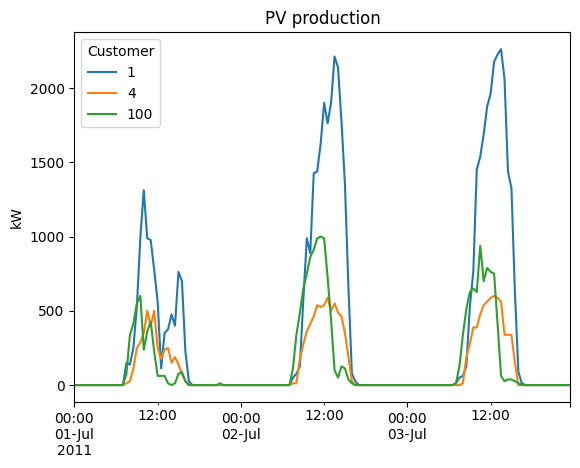

In [53]:
dfGG[[1, 4, 100]]['2011-07-01':'2011-07-03'].plot()
plt.title('PV production')
plt.ylabel('kW')
plt.savefig('../figs/ausgrid_explore/PV production 2011-07 01-03.png', dpi=150)

## Reorganize the data
Now we have MultiIndex columns in `df`, with Customer and Channel as the second level.

We want to have a SingleIndex columns, with names like 1_GC, 1_GG, 2_GC, 2_GG, etc.

In [54]:
df.head()

Customer                1                   2                3                 \
Channel                  GC   GG      CL     GC   GG   CL     GC   GG      CL   
2011-07-01 00:00:00  2154.0  0.0  2500.0  552.0  0.0  0.0  120.0  0.0  4016.0   
2011-07-01 00:30:00  1338.0  0.0  2500.0  268.0  0.0  0.0  124.0  0.0   436.0   
2011-07-01 01:00:00  1348.0  0.0  2500.0  338.0  0.0  0.0  120.0  0.0     0.0   
2011-07-01 01:30:00  1230.0  0.0  1250.0  370.0  0.0  0.0  118.0  0.0     0.0   
2011-07-01 02:00:00   642.0  0.0   438.0  282.0  0.0  0.0  120.0  0.0     0.0   

Customer               4    ...    297                 298         299       \
Channel                 GC  ...     GC   GG      CL     GC   GG     GC   GG   
2011-07-01 00:00:00  208.0  ...  536.0  0.0     0.0  200.0  0.0  280.0  0.0   
2011-07-01 00:30:00  214.0  ...  658.0  0.0     0.0  136.0  0.0  320.0  0.0   
2011-07-01 01:00:00  208.0  ...  612.0  0.0     0.0  136.0  0.0  232.0  0.0   
2011-07-01 01:30:00  216.0  ...  466.0  0.0  2622.0  136.0  0.0  324.0  0.0   
2011-07-01 02:00:00  220.0  ...  530.0  0.0     0.0  138.0  0.0  276.0  0.0   

Customer                300               
Channel                  GC   GG      CL  
2011-07-01 00:00:00  2068.0  0.0  5066.0  
2011-07-01 00:30:00  1262.0  0.0   530.0  
2011-07-01 01:00:00   238.0  0.0     0.0  
2011-07-01 01:30:00   196.0  0.0     0.0  
2011-07-01 02:00:00   218.0  0.0     0.0  

[5 rows x 738 columns]

In [55]:
# Flatten MultiIndex columns to single-level columns
# Format: {Customer}_{Channel} (e.g., 1_GC, 1_GG, 2_GC, 2_GG, etc.)

df_flat = df.copy()
df_flat.columns = df_flat.columns.map(lambda x: f"{x[0]}_{x[1]}")
df_flat.head()

,1_GC,1_GG,1_CL,2_GC,2_GG,2_CL,3_GC,3_GG,3_CL,4_GC,...,297_GC,297_GG,297_CL,298_GC,298_GG,299_GC,299_GG,300_GC,300_GG,300_CL
2011-07-01 00:00:00,2154.0,0.0,2500.0,552.0,0.0,0.0,120.0,0.0,4016.0,208.0,...,536.0,0.0,0.0,200.0,0.0,280.0,0.0,2068.0,0.0,5066.0
2011-07-01 00:30:00,1338.0,0.0,2500.0,268.0,0.0,0.0,124.0,0.0,436.0,214.0,...,658.0,0.0,0.0,136.0,0.0,320.0,0.0,1262.0,0.0,530.0
2011-07-01 01:00:00,1348.0,0.0,2500.0,338.0,0.0,0.0,120.0,0.0,0.0,208.0,...,612.0,0.0,0.0,136.0,0.0,232.0,0.0,238.0,0.0,0.0
2011-07-01 01:30:00,1230.0,0.0,1250.0,370.0,0.0,0.0,118.0,0.0,0.0,216.0,...,466.0,0.0,2622.0,136.0,0.0,324.0,0.0,196.0,0.0,0.0
2011-07-01 02:00:00,642.0,0.0,438.0,282.0,0.0,0.0,120.0,0.0,0.0,220.0,...,530.0,0.0,0.0,138.0,0.0,276.0,0.0,218.0,0.0,0.0


To put GG, GC, CL into our case，create a new dataframe with the following rules for each customer:
pv=GG
con=GC+CL
net=con-pv
note that some customers have no CL, so we need to fill the NaN values with 0.
Let's start from `df_flat`.

In [56]:
# Efficient implementation using pd.concat to avoid DataFrame fragmentation
# Starting from df_flat with columns like 1_GC, 1_GG, 1_CL, 2_GC, 2_GG, 2_CL, etc.

# Get all unique customers
customers = sorted([int(col.split('_')[0])
                   for col in df_flat.columns if '_' in col])
customers = list(set(customers))

# Prepare data for each customer in a list of DataFrames
customer_dfs = []

for customer in customers:
    # Create a temporary DataFrame for this customer
    temp_df = pd.DataFrame(index=df_flat.index)

    # PV generation (GG)
    pv_col = f"{customer}_GG"
    if pv_col in df_flat.columns:
        temp_df[f"{customer}_pv"] = df_flat[pv_col]
    else:
        temp_df[f"{customer}_pv"] = 0

    # Total consumption (GC + CL, with CL filled with 0 if missing)
    gc_col = f"{customer}_GC"
    cl_col = f"{customer}_CL"

    if gc_col in df_flat.columns:
        gc_values = df_flat[gc_col]
    else:
        gc_values = 0

    if cl_col in df_flat.columns:
        cl_values = df_flat[cl_col].fillna(0)  # Fill NaN with 0
    else:
        cl_values = 0

    temp_df[f"{customer}_con"] = gc_values
    # temp_df[f"{customer}_con"] = gc_values + cl_values

    # Net consumption (con - pv)
    temp_df[f"{customer}_net"] = temp_df[f"{customer}_con"] - \
        temp_df[f"{customer}_pv"]

    customer_dfs.append(temp_df)

# Concatenate all customer DataFrames at once (this avoids fragmentation)
df_our_case = pd.concat(customer_dfs, axis=1)

# Optional: defragment the final DataFrame
df_our_case = df_our_case.copy()

# Display the result
print("New dataframe structure:")
print(f"Shape: {df_our_case.shape}")
print(f"Columns: {list(df_our_case.columns)[:10]}...")  # Show first 10 columns
df_our_case.head()

New dataframe structure:
Shape: (17568, 900)
Columns: ['1_pv', '1_con', '1_net', '2_pv', '2_con', '2_net', '3_pv', '3_con', '3_net', '4_pv']...


,1_pv,1_con,1_net,2_pv,2_con,2_net,3_pv,3_con,3_net,4_pv,...,297_net,298_pv,298_con,298_net,299_pv,299_con,299_net,300_pv,300_con,300_net
2011-07-01 00:00:00,0.0,2154.0,2154.0,0.0,552.0,552.0,0.0,120.0,120.0,0.0,...,536.0,0.0,200.0,200.0,0.0,280.0,280.0,0.0,2068.0,2068.0
2011-07-01 00:30:00,0.0,1338.0,1338.0,0.0,268.0,268.0,0.0,124.0,124.0,0.0,...,658.0,0.0,136.0,136.0,0.0,320.0,320.0,0.0,1262.0,1262.0
2011-07-01 01:00:00,0.0,1348.0,1348.0,0.0,338.0,338.0,0.0,120.0,120.0,0.0,...,612.0,0.0,136.0,136.0,0.0,232.0,232.0,0.0,238.0,238.0
2011-07-01 01:30:00,0.0,1230.0,1230.0,0.0,370.0,370.0,0.0,118.0,118.0,0.0,...,466.0,0.0,136.0,136.0,0.0,324.0,324.0,0.0,196.0,196.0
2011-07-01 02:00:00,0.0,642.0,642.0,0.0,282.0,282.0,0.0,120.0,120.0,0.0,...,530.0,0.0,138.0,138.0,0.0,276.0,276.0,0.0,218.0,218.0


In [57]:
# make the datetime a column and put it first
df_our_case['datetime'] = df_our_case.index
df_our_case = df_our_case[['datetime'] +
                          [col for col in df_our_case.columns if col != 'datetime']]
# set the index to [0, 1, 2, ...]
df_our_case.index = range(len(df_our_case))
df_our_case.head()

,datetime,1_pv,1_con,1_net,2_pv,2_con,2_net,3_pv,3_con,3_net,...,297_net,298_pv,298_con,298_net,299_pv,299_con,299_net,300_pv,300_con,300_net
0,2011-07-01 00:00:00,0.0,2154.0,2154.0,0.0,552.0,552.0,0.0,120.0,120.0,...,536.0,0.0,200.0,200.0,0.0,280.0,280.0,0.0,2068.0,2068.0
1,2011-07-01 00:30:00,0.0,1338.0,1338.0,0.0,268.0,268.0,0.0,124.0,124.0,...,658.0,0.0,136.0,136.0,0.0,320.0,320.0,0.0,1262.0,1262.0
2,2011-07-01 01:00:00,0.0,1348.0,1348.0,0.0,338.0,338.0,0.0,120.0,120.0,...,612.0,0.0,136.0,136.0,0.0,232.0,232.0,0.0,238.0,238.0
3,2011-07-01 01:30:00,0.0,1230.0,1230.0,0.0,370.0,370.0,0.0,118.0,118.0,...,466.0,0.0,136.0,136.0,0.0,324.0,324.0,0.0,196.0,196.0
4,2011-07-01 02:00:00,0.0,642.0,642.0,0.0,282.0,282.0,0.0,120.0,120.0,...,530.0,0.0,138.0,138.0,0.0,276.0,276.0,0.0,218.0,218.0


In [58]:
# add HoD dow doy month	year
from modules.utils import add_datetime_columns
df_our_case = add_datetime_columns(df_our_case)
df_our_case.head()

,datetime,HoD,dow,doy,month,year,1_pv,1_con,1_net,2_pv,...,297_net,298_pv,298_con,298_net,299_pv,299_con,299_net,300_pv,300_con,300_net
0,2011-07-01 00:00:00,0,4,182,7,2011,0.0,2154.0,2154.0,0.0,...,536.0,0.0,200.0,200.0,0.0,280.0,280.0,0.0,2068.0,2068.0
1,2011-07-01 00:30:00,0,4,182,7,2011,0.0,1338.0,1338.0,0.0,...,658.0,0.0,136.0,136.0,0.0,320.0,320.0,0.0,1262.0,1262.0
2,2011-07-01 01:00:00,1,4,182,7,2011,0.0,1348.0,1348.0,0.0,...,612.0,0.0,136.0,136.0,0.0,232.0,232.0,0.0,238.0,238.0
3,2011-07-01 01:30:00,1,4,182,7,2011,0.0,1230.0,1230.0,0.0,...,466.0,0.0,136.0,136.0,0.0,324.0,324.0,0.0,196.0,196.0
4,2011-07-01 02:00:00,2,4,182,7,2011,0.0,642.0,642.0,0.0,...,530.0,0.0,138.0,138.0,0.0,276.0,276.0,0.0,218.0,218.0


## Save the data

In [59]:
df_our_case.to_csv('../data/ausgrid/ausgrid_2011_2012.csv')